In [1]:
import pandas as pd

df = pd.read_csv(
    "dataset_updated.csv",
    sep=";",
    header=1,
    decimal=",",
    encoding="utf-8-sig",
)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

df.columns = df.columns.str.strip()

print(
    f" Таблица загружена: {df.shape[0]} строк, {df.shape[1]} колонок"
)
print("\nСписок колонок:")
print(df.columns.tolist()[:10], "... и другие")

display(df.head())

 Таблица загружена: 374 строк, 42 колонок

Список колонок:
['country', 'year', 'infant_mortality', 'migration', 'natural_increase', 'fertility_rate', 'death_rate', 'internet_users', 'using_birth_control', 'mother_death'] ... и другие


,country,year,infant_mortality,migration,natural_increase,fertility_rate,death_rate,internet_users,using_birth_control,mother_death,...,water_withdraw_bcm,water_withdraw_pct,dep_young,dep_old,dep_total,teen_fertility,hh_cons_usd,hh_cons_const,museum_visits,theaters_visits
0,Азербайджан,1991,25.3,-40.1,20.4,26.6,6.2,NaN,NaN,NaN,...,NaN,NaN,47.332684,8.274349,55.607033,79.881,1.185714e+09,NaN,357.0,218.0
1,Азербайджан,1992,25.5,-14.2,17.9,25.0,7.1,NaN,NaN,NaN,...,NaN,NaN,48.945994,9.091162,58.037157,87.876,1.198277e+09,NaN,275.0,186.0
2,Азербайджан,1993,28.2,-12.2,16.5,23.7,7.2,NaN,NaN,NaN,...,3.198,46.624872,51.227522,10.256699,61.484221,85.512,1.121936e+09,NaN,306.0,212.0
3,Азербайджан,1994,25.2,-11.0,14.1,21.4,7.3,NaN,NaN,NaN,...,2.983,43.490305,52.380366,11.357734,63.738100,78.461,1.240031e+09,2.886106e+09,210.0,192.0
4,Азербайджан,1995,23.3,-9.8,12.2,18.9,6.7,NaN,NaN,NaN,...,2.531,36.900423,52.413439,12.280731,64.694169,70.655,1.558291e+09,3.164668e+09,204.0,159.0


In [18]:
# отобранные колонки
core_features = [
    "country",
    "year",
    "tfr",
    "natural_increase",
    "dep_young",
    "dep_old",
    "life_expectancy",
    "infant_mortality",
    "gdp_percapita",
    "gni_percapita",
    "hh_cons_usd",
    "Unemployment",
    "Employment",
    "water_withdraw_pct",
    "dep_total",
    "apartments_built",
    "migration",
    "marriages",
    "divorces",
    "internet_users",
    "high_educ",
    "death_rate",
    "fertility_rate",
    "museum_visits",
    "theaters_visits"
]

# чистый датасет
df_analysis = df[core_features].copy()
df_analysis = df_analysis.sort_values(by=["country", "year"]).reset_index(
    drop=True
)

display(df_analysis.head(5))

# описательная статистика (среднее, медиана, мин/макс)
print("\n Описательная статистика:")
display(df_analysis.describe().T[["mean", "std", "min", "50%", "max"]])

,country,year,tfr,natural_increase,dep_young,dep_old,life_expectancy,infant_mortality,gdp_percapita,gni_percapita,...,apartments_built,migration,marriages,divorces,internet_users,high_educ,death_rate,fertility_rate,museum_visits,theaters_visits
0,Азербайджан,1991,NaN,20.4,47.332684,8.274349,66.3,25.3,5412.097602,NaN,...,40.0,-40.1,10.4,1.5,NaN,150.0,6.2,26.6,357.0,218.0
1,Азербайджан,1992,NaN,17.9,48.945994,9.091162,65.4,25.5,4220.146373,160.0,...,33.0,-14.2,9.5,1.3,NaN,136.0,7.1,25.0,275.0,186.0
2,Азербайджан,1993,NaN,16.5,51.227522,10.256699,65.2,28.2,3272.237950,110.0,...,23.0,-12.2,8.1,0.9,NaN,127.0,7.2,23.7,306.0,212.0
3,Азербайджан,1994,NaN,14.1,52.380366,11.357734,65.2,25.2,2647.765384,80.0,...,12.0,-11.0,6.3,0.8,NaN,119.0,7.3,21.4,210.0,192.0
4,Азербайджан,1995,NaN,12.2,52.413439,12.280731,65.2,23.3,2356.897801,180.0,...,9.0,-9.8,5.7,0.8,NaN,130.0,6.7,18.9,204.0,159.0



 Описательная статистика:


,mean,std,min,50%,max
year,2.007500e+03,9.823851e+00,1.991000e+03,2.007500e+03,2.024000e+03
tfr,1.947162e+00,6.572641e-01,6.000000e-01,1.750000e+00,3.600000e+00
natural_increase,7.729335e+00,1.031363e+01,-1.120000e+01,6.200000e+00,3.300000e+01
dep_young,4.174895e+01,1.625692e+01,1.983196e+01,4.021752e+01,8.728979e+01
dep_old,1.290245e+01,6.054967e+00,4.860571e+00,1.045777e+01,2.823935e+01
life_expectancy,6.664933e+01,3.983390e+00,5.640000e+01,6.665000e+01,7.530000e+01
infant_mortality,1.378194e+01,6.748284e+00,2.400000e+00,1.210000e+01,3.740000e+01
gdp_percapita,9.570425e+03,8.377551e+03,8.364291e+02,6.572401e+03,4.768607e+04
gni_percapita,3.057201e+03,3.119933e+03,0.000000e+00,1.735000e+03,1.533000e+04
hh_cons_usd,7.741860e+10,2.036773e+11,2.093153e+08,9.931612e+09,1.218810e+12


In [19]:
# csv_filename = "selected_features.csv"
# excel_filename = "selected_features.xlsx"

# df_analysis.to_csv(csv_filename, index=False, encoding="utf-8-sig")

# df_analysis.to_excel(excel_filename, index=False, sheet_name="CIS_Core_Data")

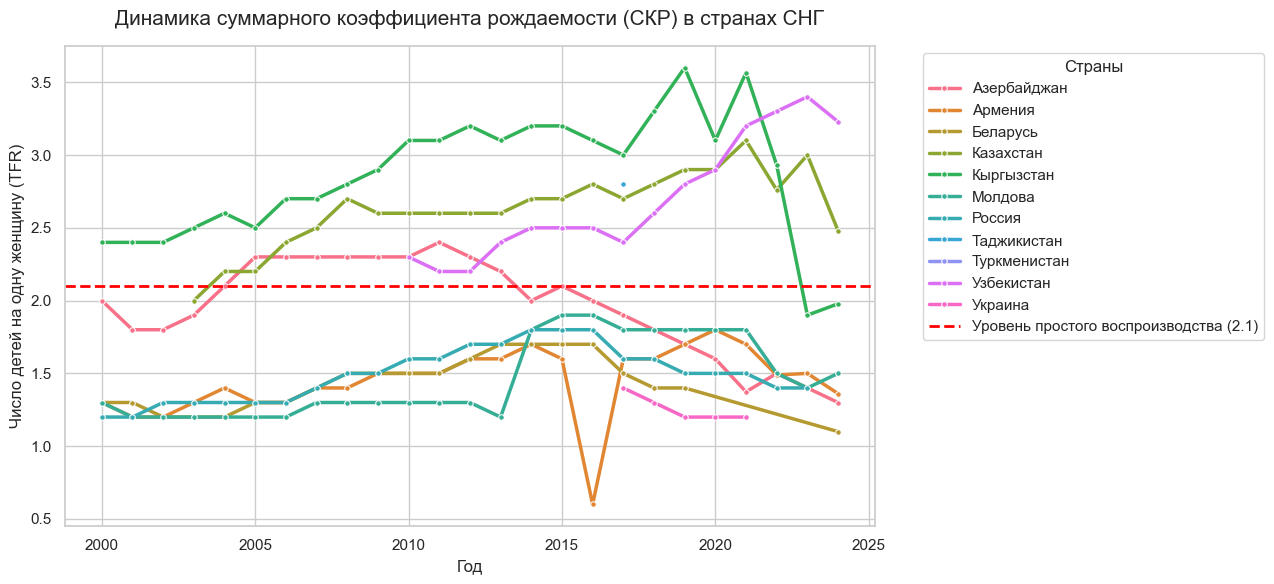

In [7]:
# Динамика рождаемости (СКР) по странам СНГ

plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df_analysis,
    x="year",
    y="tfr",
    hue="country",
    linewidth=2.5,
    marker="o",
    markersize=4,
)

# Линия простого воспроизводства населения (2.1 ребенка)
plt.axhline(
    2.1,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Уровень простого воспроизводства (2.1)",
)

plt.title(
    "Динамика суммарного коэффициента рождаемости (СКР) в странах СНГ",
    fontsize=15,
    pad=15,
)
plt.xlabel("Год", fontsize=12)
plt.ylabel("Число детей на одну женщину (TFR)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Страны")
plt.tight_layout()
plt.show()

In [16]:
target_year = 2024

df_2024 = df_analysis[
    (df_analysis["year"] == target_year) & (df_analysis["country"] != "Украина")
].copy()

df_2024 = df_2024.sort_values(by="country").reset_index(drop=True)

display(df_2024)

df_2024.to_excel(f"data_{target_year}.xlsx", index=False)

,country,year,tfr,natural_increase,dep_young,dep_old,life_expectancy,infant_mortality,health_exp_pc,med_stuff,...,hh_cons_usd,Unemployment,apartments_built,migration,marriages,divorces,internet_users,high_educ,death_rate,fertility_rate
0,Азербайджан,2024,1.300,4.200000,28.686310,20.433571,74.538827,13.9,NaN,2.800000,...,1.773206e+10,12.900000,25.4,-1.1,4.90,2.10,NaN,241.0,5.80,10.000000
1,Армения,2024,1.361,2.700000,31.323883,12.287008,75.100000,6.2,NaN,0.300000,...,4.164259e+10,27.300000,33.7,NaN,5.10,1.60,NaN,277.0,8.40,11.100000
2,Беларусь,2024,1.100,-6.100000,24.679224,26.752848,NaN,2.9,NaN,11.400000,...,4.347186e+10,10.100000,53.0,NaN,5.10,3.80,NaN,258.0,12.60,6.500000
3,Казахстан,2024,2.480,11.600000,47.396531,13.962797,71.330000,6.8,NaN,9.809500,...,1.523730e+11,3.700000,86.0,128.2,6.13,2.01,NaN,310.0,6.59,18.200000
4,Кыргызстан,2024,1.978,15.000000,52.183591,9.167890,68.445386,13.1,NaN,2.400000,...,1.596893e+10,8.000000,21.0,23.5,6.20,1.80,NaN,350.0,4.40,19.400000
5,Молдова,2024,1.500,-4.105222,30.920018,25.330576,67.600000,11.8,NaN,3.351076,...,1.558211e+10,9.758831,20.0,-12.6,6.20,4.00,NaN,247.0,13.90,9.843875
6,Россия,2024,NaN,NaN,26.361365,26.207475,NaN,NaN,NaN,11.100000,...,1.080420e+12,8.500000,93.0,NaN,NaN,NaN,NaN,304.0,NaN,NaN
7,Таджикистан,2024,NaN,22.000000,60.549782,6.431562,75.300000,7.8,NaN,1.400000,...,1.336662e+10,NaN,17.5,NaN,7.50,0.90,NaN,203.0,3.20,25.200000
8,Туркменистан,2024,NaN,NaN,49.258026,7.082611,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Узбекистан,2024,3.229,20.200000,49.345408,9.304021,72.860813,9.0,NaN,4.810995,...,7.912867e+10,5.500000,20.0,8.5,7.30,1.20,NaN,382.0,4.70,24.900000


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_2024 = pd.read_csv("data_2024.csv", sep=";", decimal=",", encoding="utf-8")

df_2024 = df_2024.dropna(subset=["country"])
df_2024 = df_2024[df_2024["country"].str.strip() != ""]

cols_to_clean = [col for col in df_2024.columns if col not in ["country", "year"]]

for col in cols_to_clean:
    df_2024[col] = (
        df_2024[col]
        .astype(str)
        .str.replace("\xa0", "", regex=False)  
        .str.replace(" ", "", regex=False)  
        .str.replace(",", ".", regex=False)  
    )
    df_2024[col] = pd.to_numeric(df_2024[col], errors="coerce")

pd.set_option("display.float_format", "{:.2f}".format)

print(f" Данные за 2024 год загружены: {df_2024.shape[0]} стран")
display(df_2024)

 Данные за 2024 год загружены: 10 стран


,country,year,tfr,dep_old,life_expectancy,infant_mortality,gdp_percapita,gni_percapita,hh_cons_usd,Unemployment,apartments_built,internet_users,high_educ,depopulation_rate,marriage_vitality
0,Азербайджан,2024.00,1.30,20.43,74.54,13.90,25146.36,7340.00,11416992852.00,12.90,25.40,89.00,241.00,0.58,2.33
1,Армения,2024.00,1.36,12.29,75.10,6.20,22856.33,7810.00,10051983517.00,27.30,33.70,80.00,277.00,0.76,3.19
2,Беларусь,2024.00,1.10,26.75,74.70,2.90,33166.38,8380.00,42930104149.00,10.10,53.00,94.30,258.00,1.94,1.34
3,Казахстан,2024.00,2.48,13.96,71.33,6.80,40950.32,12100.00,139806000000.00,3.70,86.00,93.40,310.00,0.36,3.05
4,Кыргызстан,2024.00,1.98,9.17,68.45,13.10,8208.03,2260.00,11834537154.00,8.00,21.00,92.00,350.00,0.23,3.44
5,Молдова,2024.00,1.50,25.33,67.60,11.80,18661.66,6890.00,8207052859.00,9.76,20.00,77.40,247.00,1.41,1.55
6,Россия,2024.00,1.40,26.21,72.80,4.05,47686.07,15330.00,921581000000.00,8.50,93.00,94.40,304.00,1.49,1.36
7,Таджикистан,2024.00,3.04,6.43,75.30,7.80,5413.83,1650.00,11964352707.00,7.00,17.50,55.80,203.00,0.13,8.33
8,Туркменистан,2024.00,2.80,7.08,70.20,30.40,21025.84,5640.00,NaN,4.20,NaN,46.10,95.00,0.28,6.36
9,Узбекистан,2024.00,3.23,9.30,72.86,9.00,12518.43,5230.00,126853000000.00,5.50,20.00,89.00,382.00,0.19,6.08


In [5]:
# описательная статистика 2024 года
stats_summary = df_2024[cols_to_clean].describe().T[
    ["mean", "std", "min", "50%", "max"]
]
stats_summary.columns = [
    "Среднее",
    "Станд. отклонение",
    "Минимум",
    "Медиана",
    "Максимум",
]

print("Описательная статистика ключевых показателей СНГ за 2024 год:")
display(stats_summary)

Описательная статистика ключевых показателей СНГ за 2024 год:


,Среднее,Станд. отклонение,Минимум,Медиана,Максимум
tfr,2.02,0.80,1.10,1.74,3.23
dep_old,15.70,8.21,6.43,13.12,26.75
life_expectancy,72.29,2.80,67.60,72.83,75.30
infant_mortality,10.59,7.87,2.90,8.40,30.40
gdp_percapita,23563.32,13731.89,5413.83,21941.08,47686.07
gni_percapita,7263.00,4129.41,1650.00,7115.00,15330.00
hh_cons_usd,142738335915.33,296649159279.47,8207052859.00,11964352707.00,921581000000.00
Unemployment,9.70,6.80,3.70,8.25,27.30
apartments_built,41.07,29.59,17.50,25.40,93.00
internet_users,81.14,17.08,46.10,89.00,94.40


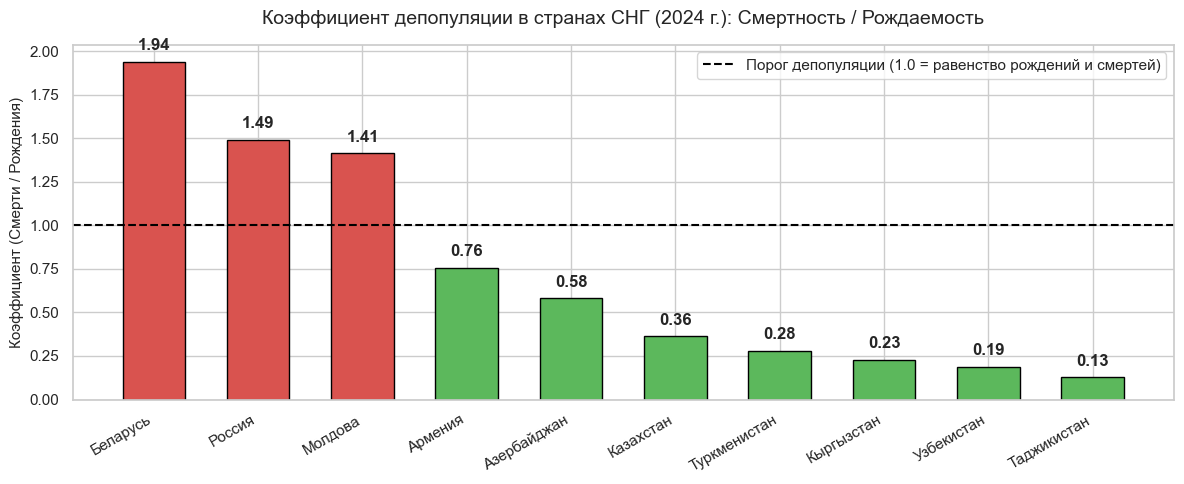

In [22]:
plt.figure(figsize=(12, 5))
df_sorted_dep = df_2024.sort_values(by="depopulation_rate", ascending=False)

colors = [
    "#d9534f" if x > 1.0 else "#5cb85c"
    for x in df_sorted_dep["depopulation_rate"]
]

bars = plt.bar(
    df_sorted_dep["country"],
    df_sorted_dep["depopulation_rate"],
    color=colors,
    edgecolor="black",
    width=0.6,
)
plt.axhline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Порог депопуляции (1.0 = равенство рождений и смертей)",
)

for bar in bars:
    yval = bar.get_height()
    if not np.isnan(yval):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.05,
            f"{yval:.2f}",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

plt.title(
    "Коэффициент депопуляции в странах СНГ (2024 г.): Смертность / Рождаемость",
    fontsize=14,
    pad=15,
)
plt.ylabel("Коэффициент (Смерти / Рождения)", fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=11)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

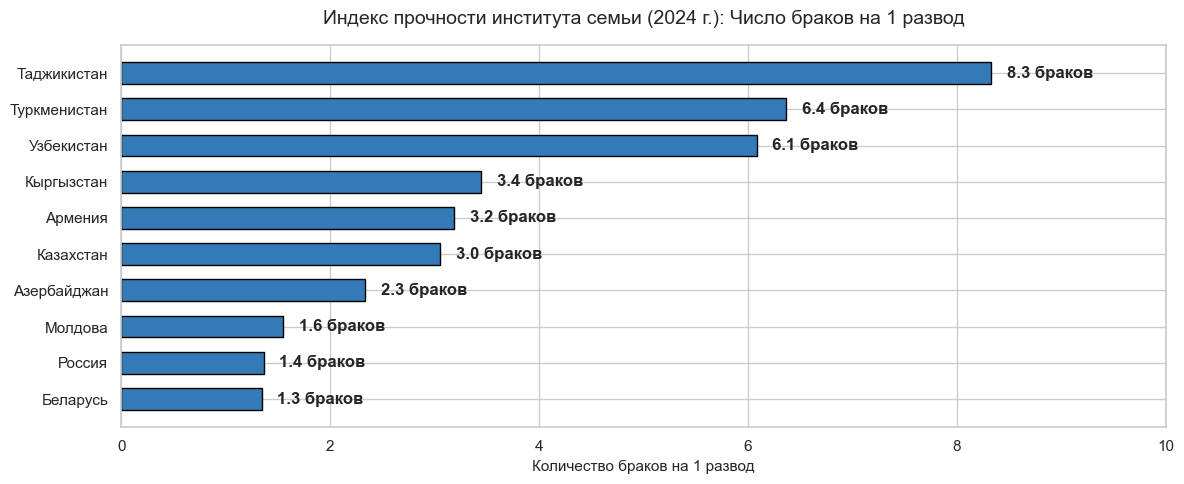

In [23]:
plt.figure(figsize=(12, 5))
df_sorted_mar = df_2024.sort_values(by="marriage_vitality", ascending=True)

bars2 = plt.barh(
    df_sorted_mar["country"],
    df_sorted_mar["marriage_vitality"],
    color="#337ab7",
    edgecolor="black",
    height=0.6,
)

for bar in bars2:
    xval = bar.get_width()
    if not np.isnan(xval):
        plt.text(
            xval + 0.15,
            bar.get_y() + bar.get_height() / 2,
            f"{xval:.1f} браков",
            ha="left",
            va="center",
            fontweight="bold",
        )

plt.title(
    "Индекс прочности института семьи (2024 г.): Число браков на 1 развод",
    fontsize=14,
    pad=15,
)
plt.xlabel("Количество браков на 1 развод", fontsize=11)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

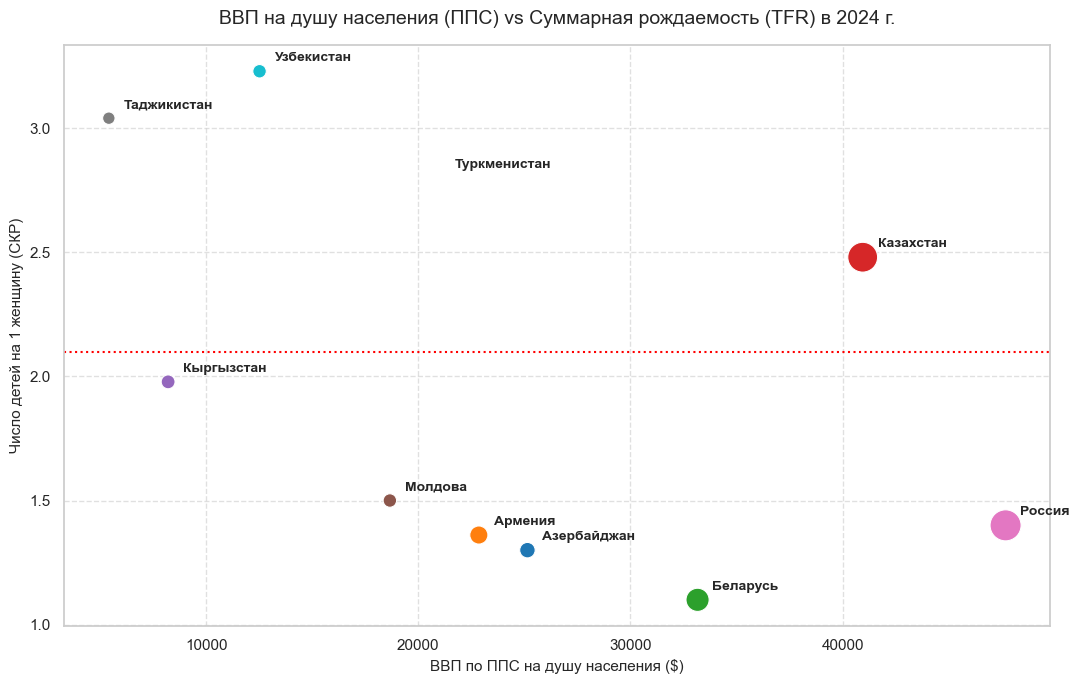

In [24]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df_2024,
    x="gdp_percapita",
    y="tfr",
    size="apartments_built",
    sizes=(80, 500),
    hue="country",
    palette="tab10",
    legend=False,
)

plt.axhline(2.1, color="red", linestyle=":", label="Воспроизводство (2.1)")

for i in range(len(df_2024)):
    row = df_2024.iloc[i]
    if not np.isnan(row["gdp_percapita"]) and not np.isnan(row["tfr"]):
        plt.annotate(
            row["country"],
            (row["gdp_percapita"] + 700, row["tfr"] + 0.04),
            fontsize=10,
            fontweight="bold",
        )

plt.title(
    "ВВП на душу населения (ППС) vs Суммарная рождаемость (TFR) в 2024 г.",
    fontsize=14,
    pad=15,
)
plt.xlabel("ВВП по ППС на душу населения ($)", fontsize=11)
plt.ylabel("Число детей на 1 женщину (СКР)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

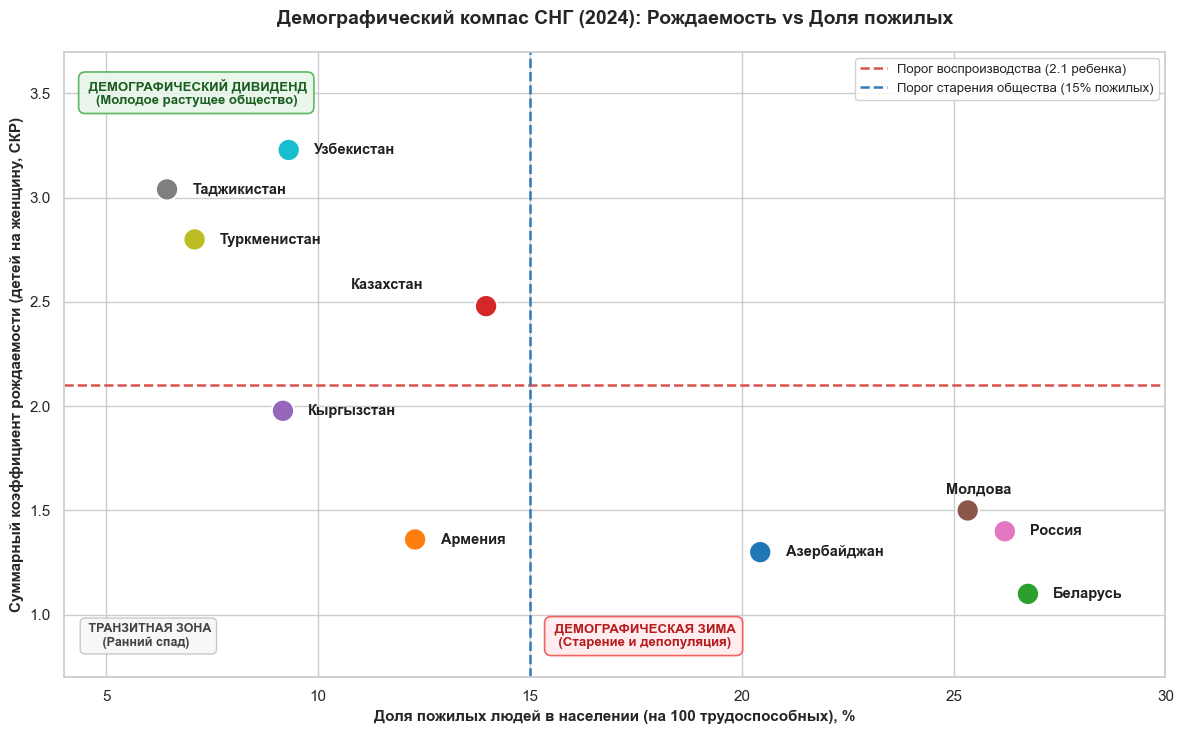

In [6]:
plt.figure(figsize=(12, 7.5))
sns.set_theme(style="whitegrid")

plt.xlim(4, 30)
plt.ylim(0.7, 3.7)

plt.axhline(
    2.1,
    color="#d9534f",
    linestyle="--",
    linewidth=1.8,
    label="Порог воспроизводства (2.1 ребенка)",
)
plt.axvline(
    15.0,
    color="#337ab7",
    linestyle="--",
    linewidth=1.8,
    label="Порог старения общества (15% пожилых)",
)

plt.text(
    4.5,
    3.45,
    " ДЕМОГРАФИЧЕСКИЙ ДИВИДЕНД\n   (Молодое растущее общество)",
    fontsize=9.5,
    color="#1b5e20",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5", fc="#e8f5e9", ec="#4caf50", lw=1.2, alpha=0.9
    ),
)

plt.text(
    15.5,
    0.85,
    " ДЕМОГРАФИЧЕСКАЯ ЗИМА\n  (Старение и депопуляция)",
    fontsize=9.5,
    color="#b71c1c",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5", fc="#ffebee", ec="#ef5350", lw=1.2, alpha=0.9
    ),
)

plt.text(
    4.5,
    0.85,
    " ТРАНЗИТНАЯ ЗОНА\n     (Ранний спад)",
    fontsize=9,
    color="#424242",
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#bdbdbd", lw=1, alpha=0.8
    ),
)

sns.scatterplot(
    data=df_2024,
    x="dep_old",
    y="tfr",
    s=260,
    hue="country",
    palette="tab10",
    edgecolor="white",
    linewidth=1.5,
    legend=False,
)


custom_offsets = {
    "Казахстан": (-3.2, 0.08), 
    "Узбекистан": (0.6, -0.02),
    "Таджикистан": (0.6, -0.02),
    "Туркменистан": (0.6, -0.02),
    "Кыргызстан": (0.6, -0.02),
    "Армения": (0.6, -0.02),
    "Азербайджан": (0.6, -0.02),
    "Молдова": (-0.5, 0.08),  
    "Россия": (0.6, -0.02),
    "Беларусь": (0.6, -0.02),
}

for i in range(len(df_2024)):
    row = df_2024.iloc[i]
    c_name = row["country"]
    if not np.isnan(row["dep_old"]) and not np.isnan(row["tfr"]):
        dx, dy = custom_offsets.get(c_name, (0.5, 0.02))
        plt.annotate(
            c_name,
            (row["dep_old"] + dx, row["tfr"] + dy),
            fontsize=10.5,
            fontweight="bold",
            color="#212121",
        )

plt.title(
    "Демографический компас СНГ (2024): Рождаемость vs Доля пожилых",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel(
    "Доля пожилых людей в населении (на 100 трудоспособных), %",
    fontsize=11,
    fontweight="bold",
)
plt.ylabel(
    "Суммарный коэффициент рождаемости (детей на женщину, СКР)",
    fontsize=11,
    fontweight="bold",
)

plt.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    framealpha=0.9,
    fontsize=9.5,
)
plt.tight_layout()
plt.show()

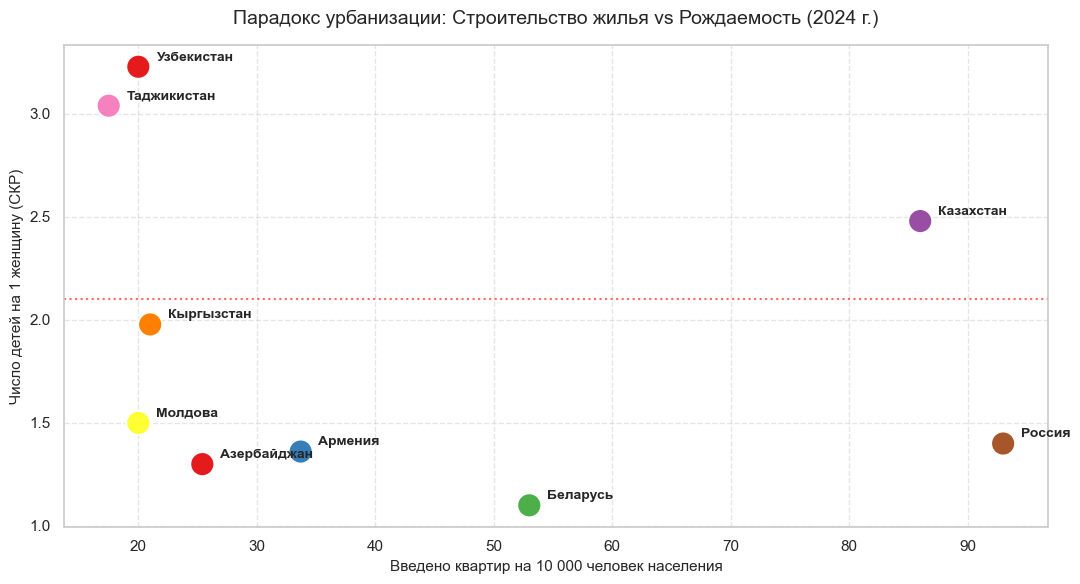

In [7]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df_2024,
    x="apartments_built",
    y="tfr",
    s=300,
    hue="country",
    palette="Set1",
    legend=False,
)

for i in range(len(df_2024)):
    row = df_2024.iloc[i]
    if not np.isnan(row["apartments_built"]) and not np.isnan(row["tfr"]):
        plt.annotate(
            row["country"],
            (row["apartments_built"] + 1.5, row["tfr"] + 0.03),
            fontsize=10,
            fontweight="bold",
        )

plt.axhline(2.1, color="red", linestyle=":", alpha=0.6)

plt.title(
    "Парадокс урбанизации: Строительство жилья vs Рождаемость (2024 г.)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Введено квартир на 10 000 человек населения", fontsize=11)
plt.ylabel("Число детей на 1 женщину (СКР)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

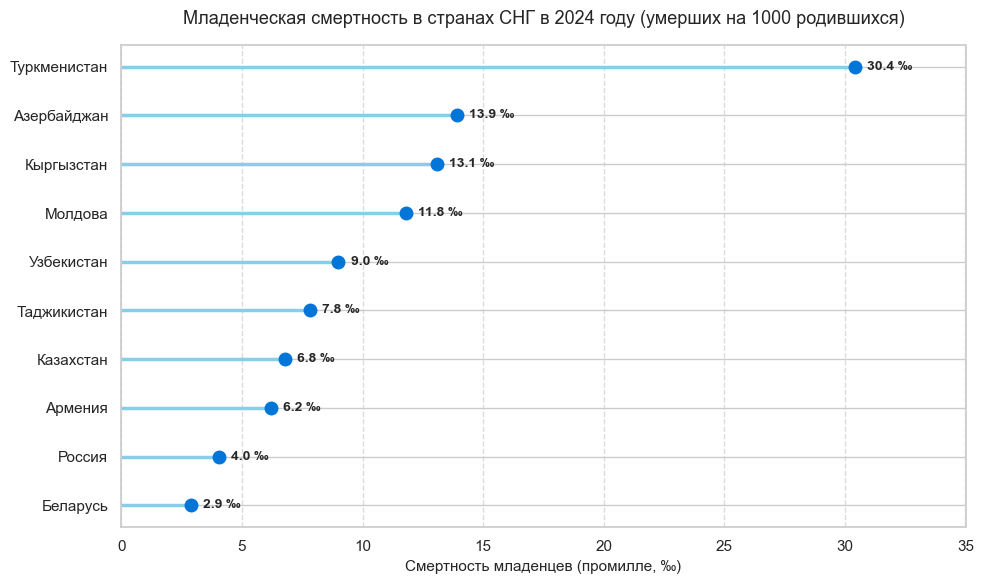

In [8]:
plt.figure(figsize=(10, 6))

df_sorted_med = df_2024.dropna(subset=["infant_mortality"]).sort_values(
    by="infant_mortality", ascending=True
)

plt.hlines(
    y=df_sorted_med["country"],
    xmin=0,
    xmax=df_sorted_med["infant_mortality"],
    color="skyblue",
    linewidth=2.5,
)
plt.plot(
    df_sorted_med["infant_mortality"],
    df_sorted_med["country"],
    "o",
    markersize=9,
    color="#0275d8",
)

for i, (val, ctry) in enumerate(
    zip(df_sorted_med["infant_mortality"], df_sorted_med["country"])
):
    plt.text(
        val + 0.5,
        i,
        f"{val:.1f} ‰",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.title(
    "Младенческая смертность в странах СНГ в 2024 году (умерших на 1000 родившихся)",
    fontsize=13,
    pad=15,
)
plt.xlabel("Смертность младенцев (промилле, ‰)", fontsize=11)
plt.xlim(0, 35)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

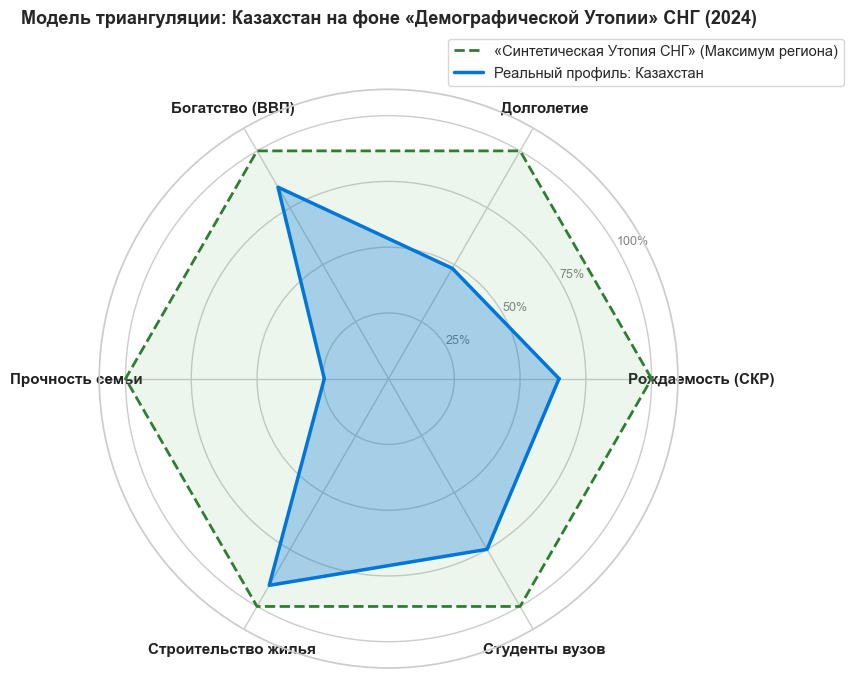

In [11]:
radar_metrics = {
    "tfr": "Рождаемость (СКР)",
    "life_expectancy": "Долголетие",
    "gdp_percapita": "Богатство (ВВП)",
    "marriage_vitality": "Прочность семьи",
    "apartments_built": "Строительство жилья",
    "high_educ": "Студенты вузов",
}

df_radar = df_2024.copy()
for col in radar_metrics.keys():
    min_val = df_radar[col].min()
    max_val = df_radar[col].max()

    df_radar[col + "_score"] = (
        (df_radar[col] - min_val) / (max_val - min_val)
    ) * 100

score_cols = [col + "_score" for col in radar_metrics.keys()]
labels = list(radar_metrics.values())
num_vars = len(labels)


utopia_values = [100] * num_vars
utopia_values += utopia_values[:1]

target_country = "Казахстан"
country_data = df_radar[df_radar["country"] == target_country][score_cols]
country_values = country_data.values.flatten().tolist()
country_values += country_values[:1]


angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

plt.xticks(angles[:-1], labels, color="#212121", size=11, fontweight="bold")
ax.set_rlabel_position(30)
plt.yticks([25, 50, 75, 100], ["25%", "50%", "75%", "100%"], color="grey", size=9)
plt.ylim(0, 110)

ax.plot(
    angles,
    utopia_values,
    linewidth=2,
    linestyle="--",
    color="#2e7d32",
    label="«Синтетическая Утопия СНГ» (Максимум региона)",
)
ax.fill(angles, utopia_values, "#4caf50", alpha=0.1)

ax.plot(
    angles,
    country_values,
    linewidth=2.5,
    linestyle="solid",
    color="#0275d8",
    label=f"Реальный профиль: {target_country}",
)
ax.fill(angles, country_values, "#0275d8", alpha=0.3)

plt.title(
    f"Модель триангуляции: {target_country} на фоне «Демографической Утопии» СНГ (2024)",
    size=13,
    fontweight="bold",
    y=1.1,
)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10.5)

plt.tight_layout()
plt.show()

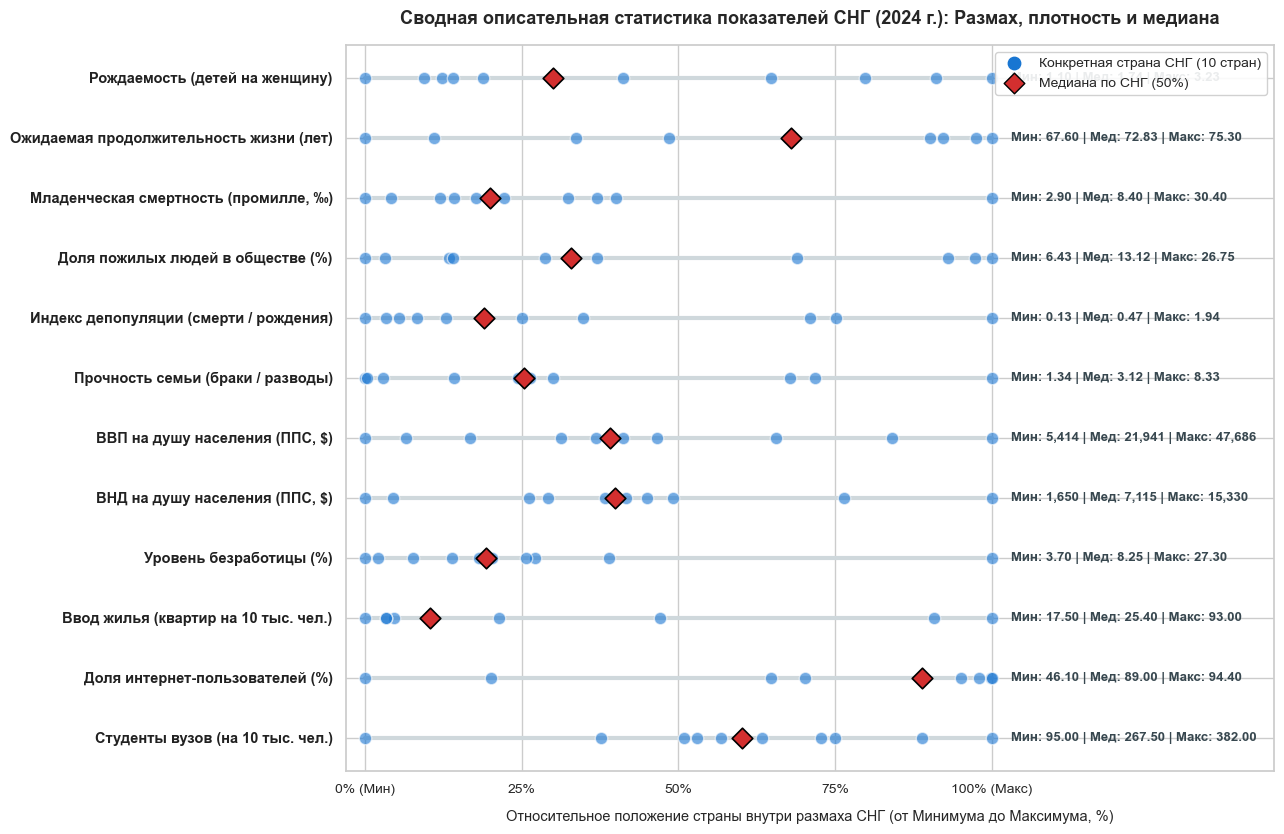

In [12]:
metrics_dict = {
    "tfr": "Рождаемость (детей на женщину)",
    "life_expectancy": "Ожидаемая продолжительность жизни (лет)",
    "infant_mortality": "Младенческая смертность (промилле, ‰)",
    "dep_old": "Доля пожилых людей в обществе (%)",
    "depopulation_rate": "Индекс депопуляции (смерти / рождения)",
    "marriage_vitality": "Прочность семьи (браки / разводы)",
    "gdp_percapita": "ВВП на душу населения (ППС, $)",
    "gni_percapita": "ВНД на душу населения (ППС, $)",
    "Unemployment": "Уровень безработицы (%)",
    "apartments_built": "Ввод жилья (квартир на 10 тыс. чел.)",
    "internet_users": "Доля интернет-пользователей (%)",
    "high_educ": "Студенты вузов (на 10 тыс. чел.)",
}

df_norm = pd.DataFrame(index=df_2024.index)
summary_text = []

for col, name in metrics_dict.items():
    series = df_2024[col].dropna()
    min_v, med_v, max_v = series.min(), series.median(), series.max()

    df_norm[col] = ((df_2024[col] - min_v) / (max_v - min_v)) * 100

    if max_v > 1000:
        summary_text.append(
            f"Мин: {min_v:,.0f} | Мед: {med_v:,.0f} | Макс: {max_v:,.0f}"
        )
    else:
        summary_text.append(
            f"Мин: {min_v:.2f} | Мед: {med_v:.2f} | Макс: {max_v:.2f}"
        )

plt.figure(figsize=(13, 8.5))
sns.set_theme(style="whitegrid")

y_positions = np.arange(len(metrics_dict))

for y in y_positions:
    plt.plot([0, 100], [y, y], color="#cfd8dc", linewidth=3, zorder=1)


for i, col in enumerate(metrics_dict.keys()):
    vals = df_norm[col].dropna()

    plt.scatter(
        vals,
        [i] * len(vals),
        color="#1976d2",
        s=80,
        alpha=0.6,
        edgecolor="white",
        zorder=3,
    )

    med_norm = ((df_2024[col].median() - df_2024[col].min()) / (df_2024[col].max() - df_2024[col].min())) * 100
    plt.scatter(
        med_norm,
        i,
        color="#d32f2f",
        marker="D",
        s=110,
        edgecolor="black",
        linewidth=1.2,
        zorder=4,
    )

    plt.text(
        103,
        i,
        summary_text[i],
        va="center",
        fontsize=9.5,
        fontweight="bold",
        color="#37474f",
    )

plt.yticks(
    y_positions,
    list(metrics_dict.values()),
    fontsize=10.5,
    fontweight="bold",
    color="#212121",
)
plt.xticks([0, 25, 50, 75, 100], ["0% (Мин)", "25%", "50%", "75%", "100% (Макс)"], fontsize=10)
plt.xlim(-3, 145)  
plt.gca().invert_yaxis()  

plt.scatter([], [], color="#1976d2", s=80, label="Конкретная страна СНГ (10 стран)")
plt.scatter(
    [],
    [],
    color="#d32f2f",
    marker="D",
    s=110,
    edgecolor="black",
    label="Медиана по СНГ (50%)",
)
plt.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9, fontsize=10)

plt.title(
    "Сводная описательная статистика показателей СНГ (2024 г.): Размах, плотность и медиана",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Относительное положение страны внутри размаха СНГ (от Минимума до Максимума, %)", fontsize=10.5, labelpad=10)
plt.tight_layout()
plt.show()